In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from skimage.transform import resize
from skimage.data import shepp_logan_phantom

In [ ]:
image = shepp_logan_phantom()
image

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(400, 400))

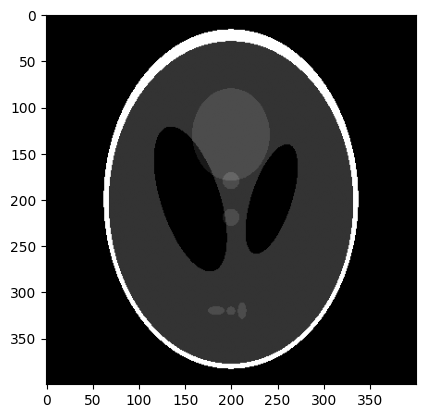

In [ ]:
plt.imshow(image, cmap='gray')

In [ ]:
image.shape

(400, 400)

In [ ]:
image = resize(image, (128, 128), anti_aliasing=True)

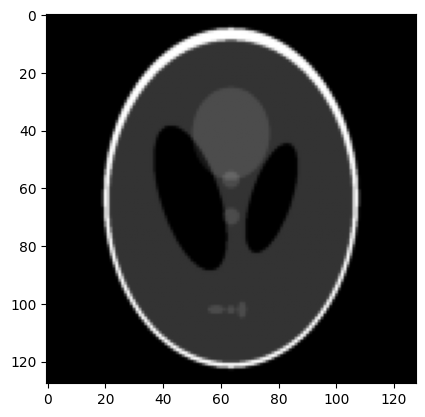

In [ ]:
plt.imshow(image, cmap='gray')
plt.savefig('radon_org.png')

In [ ]:
np.save("phantom_rad.npy", image)

### Part A and B


In [ ]:
#Interpolation function

def myXrayIntegration(theta, t, image, method,s_det=1.0):
    # print(f"value of s_det:{s_det}")
    X = image.shape[0]

    theta_rad = np.deg2rad(theta)
    
    # this is essentially trying to center the image at x0,y0 and then we have -x/2 to x/2-1 values along both directions
    # x,y defines values in XY domain
    x = np.linspace(-(X//2), (X//2)-1, X)
    y = np.linspace(-(X//2), (X//2)-1, X)

    # interpolator function
    # fill value 0 signifies that if the integral tries to access value outside bound, it becomes 0 and doesn't give bounds error
    interp2 = RegularGridInterpolator((y, x), image, fill_value=0.0, bounds_error=False)

    # maximum value for which this is considered is 
    diag = np.sqrt(2) * (X/2)
    s_vals = np.arange(-diag, diag, s_det)

    # finding the value of function for all s values given theta and t. 
    d_x = t * np.cos(theta_rad) - s_vals * np.sin(theta_rad)
    d_y = t * np.sin(theta_rad) + s_vals * np.cos(theta_rad)

    acc = np.vstack((d_y, d_x)).T
    vals = interp2(acc,method=method)
    op = np.sum(vals) * s_det
    return op


s_det is by default chosen to be 1 for a proper approximation of continuous integrals, and large value of s_det will result in undersampling and more coarse grained value results in more costlier option

s_det higher values results in less samples and hence granier results are visible




bilinear interpolation is an ideal choice when dealing with CT images for smooth and accurate approximations. High degree of interpolation will result in high computation needs as it works better for large data i.e. less costly and still good results

Nearest - too grainy , not smooth
cubic - approximates based on 16 surrounding pixels i.e. smoother than linear but more computation needs.


In [ ]:
def myXrayCTRadonTransform(image, thetas, ts, s_det=1.0,method="linear"):
    x, y  = len(ts), len(thetas)

    radom_image = np.zeros((x,y))
    '''for i, theta in enumerate(thetas):
        for j, t in enumerate(ts):
            radom_image[i,j] = myXrayIntegration(theta, t, image, s_det)'''
    for i, t in enumerate(ts):
        for j, theta in enumerate(thetas):
            radom_image[i,j] = myXrayIntegration(theta, t, image, method,s_det)

    return radom_image

In [ ]:
t_vals = np.arange(-90, 91, 5)
theta_vals = np.arange(0, 180, 5)

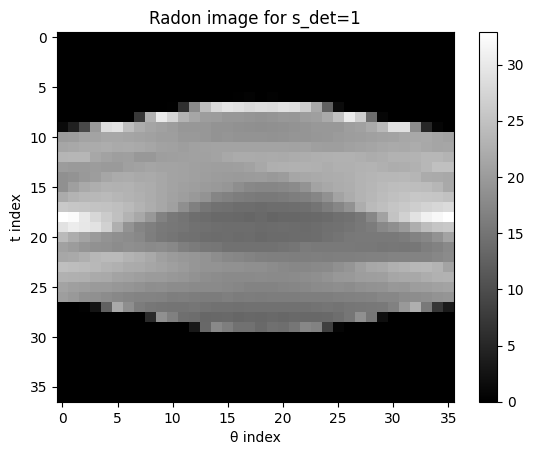

In [ ]:
# bilinear - smooth
radon_s_det_1= myXrayCTRadonTransform(image, theta_vals, t_vals, s_det=1.0,method="linear")

plt.imshow(radon_s_det_1, cmap='gray', aspect='auto')
plt.title("Radon image for s_det=1")
plt.xlabel("θ index")
plt.ylabel("t index")
plt.colorbar()

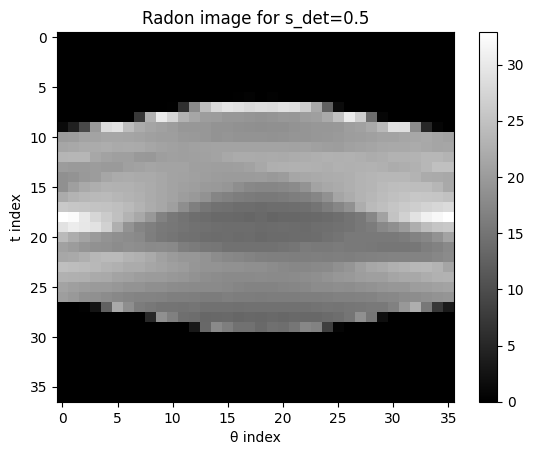

In [ ]:
# bilinear - smooth
radon_s_det_1= myXrayCTRadonTransform(image, theta_vals, t_vals, s_det=0.5,method="linear")

plt.imshow(radon_s_det_1, cmap='gray', aspect='auto')
plt.title("Radon image for s_det=0.5")
plt.xlabel("θ index")
plt.ylabel("t index")
plt.colorbar()

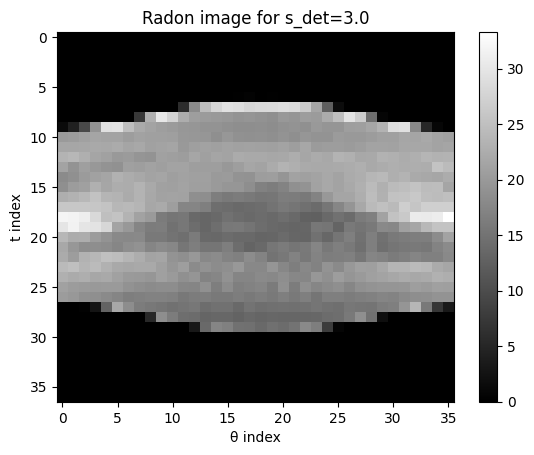

In [ ]:
# bilinear - smooth
radon_s_det_1= myXrayCTRadonTransform(image, theta_vals, t_vals, s_det=3.0,method="linear")

plt.imshow(radon_s_det_1, cmap='gray', aspect='auto')
plt.title("Radon image for s_det=3.0")
plt.xlabel("θ index")
plt.ylabel("t index")
plt.colorbar()

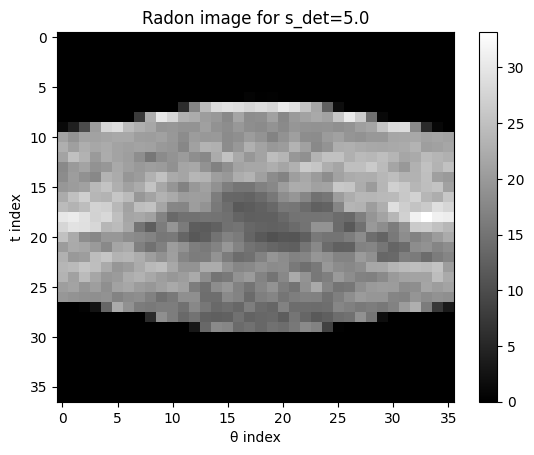

In [15]:
# bilinear - smooth
radon_s_det_1= myXrayCTRadonTransform(image, theta_vals, t_vals, s_det=5.0,method="linear")

plt.imshow(radon_s_det_1, cmap='gray', aspect='auto')
plt.title("Radon image for s_det=5.0")
plt.xlabel("θ index")
plt.ylabel("t index")
plt.colorbar()

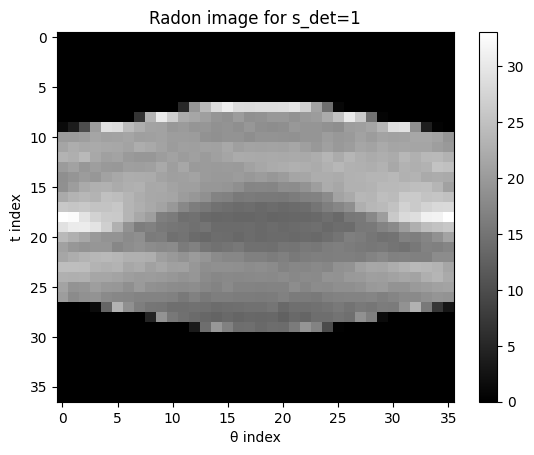

In [16]:
# nearest - not smooth
radon_s_det_1= myXrayCTRadonTransform(image, theta_vals, t_vals, s_det=1.0,method="nearest")

plt.imshow(radon_s_det_1, cmap='gray', aspect='auto')
plt.title("Radon image for s_det=1")
plt.xlabel("θ index")
plt.ylabel("t index")
plt.colorbar()

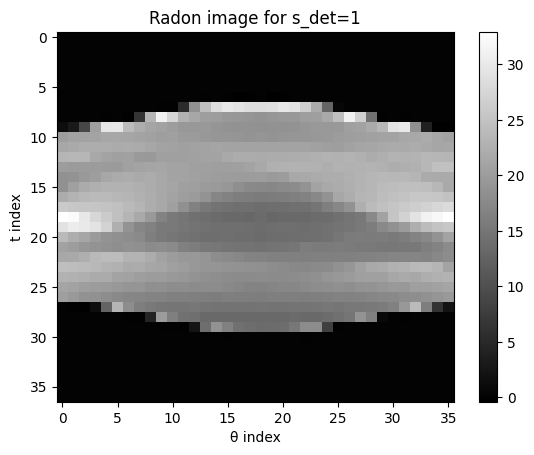

In [ ]:
# cubic 
radon_s_det_1= myXrayCTRadonTransform(image, theta_vals, t_vals, s_det=1.0,method="cubic")

plt.imshow(radon_s_det_1, cmap='jet', aspect='auto')
plt.title("Radon image for s_det=1")
plt.xlabel("θ index")
plt.ylabel("t index")
plt.colorbar()

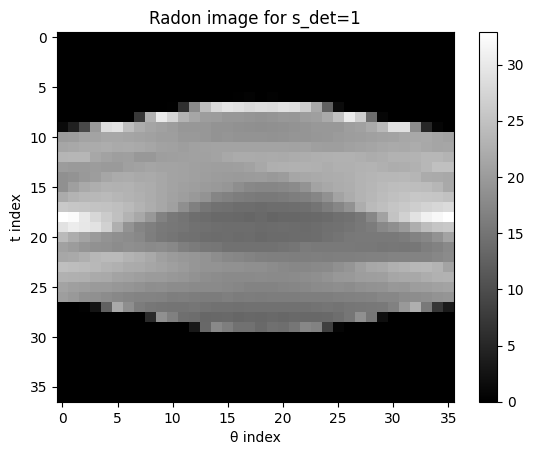

In [18]:
# slinear - actually exactly same as bilinear as it's 2D

radon_s_det_1= myXrayCTRadonTransform(image, theta_vals, t_vals, s_det=1.0,method="slinear")

plt.imshow(radon_s_det_1, cmap='gray', aspect='auto')
plt.title("Radon image for s_det=1")
plt.xlabel("θ index")
plt.ylabel("t index")
plt.colorbar()

### Part C
Testing different values of s for bilinear choice : 0.5, 1, 3

In [30]:
radon_s_det_05 = myXrayCTRadonTransform(image, theta_vals, t_vals, s_det=0.5)

In [31]:
radon_s_det_05.shape

(37, 36)

In [32]:
radon_s_det_3 = myXrayCTRadonTransform(image, theta_vals, t_vals, s_det=3.0)

In [33]:
radon_s_det_1= myXrayCTRadonTransform(image, theta_vals, t_vals, s_det=1.0,method="linear")

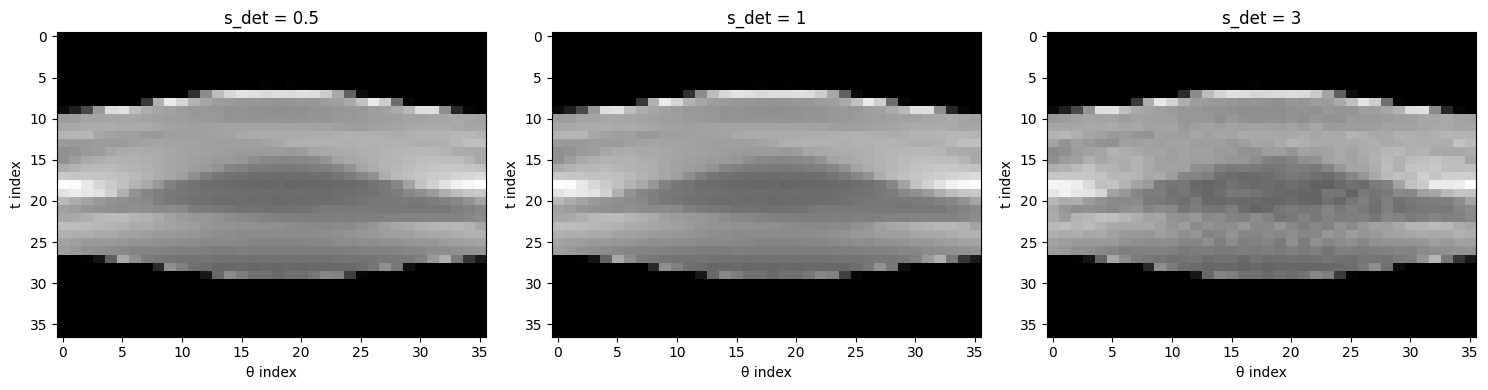

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].imshow(radon_s_det_05, cmap='gray', aspect='auto')
axs[0].set_title("s_det = 0.5")

axs[1].imshow(radon_s_det_1, cmap='gray', aspect='auto')
axs[1].set_title("s_det = 1")

axs[2].imshow(radon_s_det_3, cmap='gray', aspect='auto')
axs[2].set_title("s_det = 3")

for ax in axs:
    ax.set_xlabel("θ index")
    ax.set_ylabel("t index")

plt.tight_layout()
plt.savefig("radon_comp.png")
plt.show()

In [35]:
np.save("radon_comp_05.npy", radon_s_det_05)
np.save("radon_comp_1.npy", radon_s_det_1)
np.save("radon_comp_3.npy", radon_s_det_3)

Here for s=0.5 and 1 we are getting same values becuase the pixel width is 1 and hence taking values at smaller scale means we are just estimating values which maps to same neighbours in interpolation and hence smoothness doesn't change

In [36]:
print(len(t_vals))
print(len(theta_vals))
print(radon_s_det_05.shape)

37
36
(37, 36)


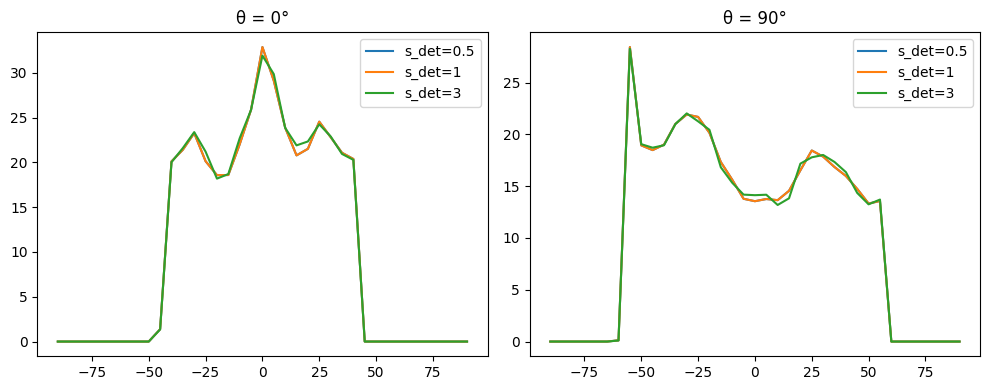

In [37]:
theta_0_idx = np.where(theta_vals == 0)[0][0]
theta_90_idx = np.where(theta_vals == 90)[0][0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(t_vals, radon_s_det_05[:, theta_0_idx], label="s_det=0.5")
plt.plot(t_vals, radon_s_det_1[:, theta_0_idx], label="s_det=1")
plt.plot(t_vals, radon_s_det_3[:, theta_0_idx], label="s_det=3")
plt.title("θ = 0°")
plt.legend()

plt.subplot(1,2,2)
plt.plot(t_vals, radon_s_det_05[:, theta_90_idx], label="s_det=0.5")
plt.plot(t_vals, radon_s_det_1[:, theta_90_idx], label="s_det=1")
plt.plot(t_vals, radon_s_det_3[:, theta_90_idx], label="s_det=3")
plt.title("θ = 90°")
plt.legend()

plt.tight_layout()
plt.savefig("radon_0-90.png")
plt.show()

As seen in the above image, the value for s_det = 0.5 and s_det = 1 is almost the same whereas the value for s_det = 3 is more rough than s_det = 1/0.5. This is because we are sampling less interval values and hence less samples, worse approximation.

difference between s_det 0.5 and 1 is small. Mathematically 0.5 will provide more smoother curve and accurate approximations. sinogram of s_det 3 is more grainy. I.e. smaller delta s actually performs better based on image visualization



#### Part - D 

In [38]:
import time

Trying for delta to be: 1
Computation time: 4.2768 seconds


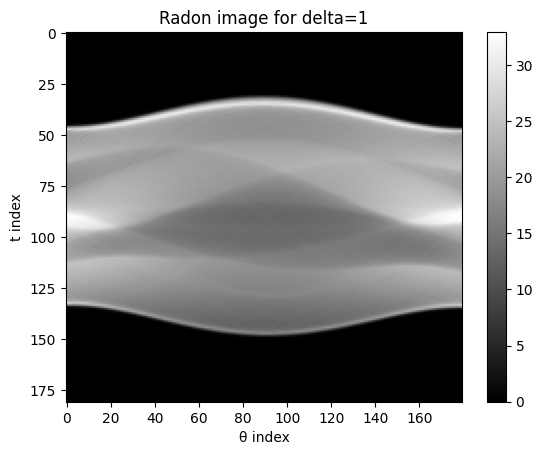

Trying for delta to be: 2
Computation time: 1.6316 seconds


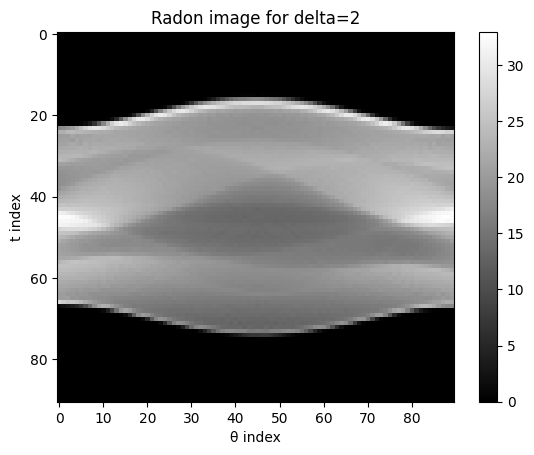

Trying for delta to be: 3
Computation time: 0.3520 seconds


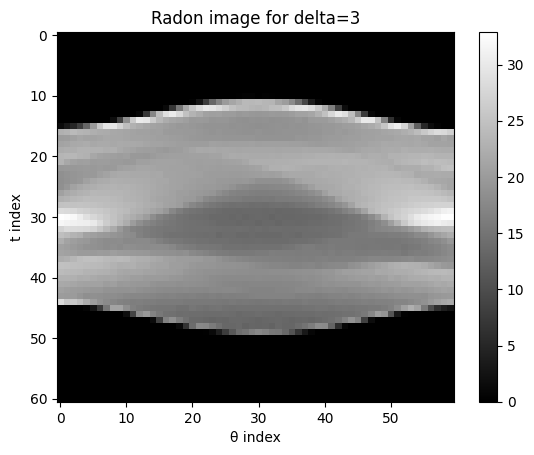

Trying for delta to be: 4
Computation time: 0.2044 seconds


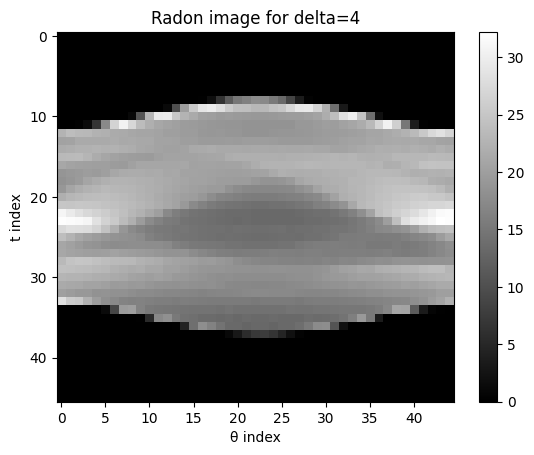

Trying for delta to be: 5
Computation time: 0.1287 seconds


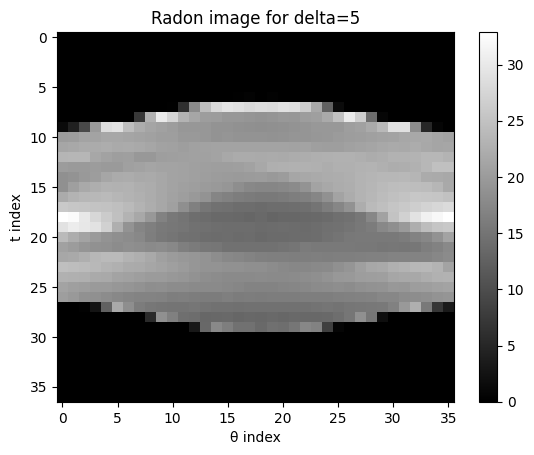

In [39]:
for delta in range(1,6):
    t_vals = np.arange(-90, 91, delta)
    theta_vals = np.arange(0, 180, delta)
    print(f"Trying for delta to be: {delta}")
    
    start_time = time.time()
    
    rd = myXrayCTRadonTransform(image, theta_vals, t_vals, 
                                s_det=1.0, method="linear")
    
    end_time = time.time()
    
    print(f"Computation time: {end_time - start_time:.4f} seconds")
    
    plt.imshow(rd, cmap='gray', aspect='auto')
    plt.title(f"Radon image for delta={delta}")
    plt.xlabel("θ index")
    plt.ylabel("t index")
    plt.colorbar()
    plt.show()

As seen above, we observe that for smaller delta's the radon transform is much smoother i.e. the value is exactly like sinogram and gets grainer as t and theta varies, but at the same time, the computation of radon transform time also increases. 

And if we use ART, the size of modelling matrix will also increase if we sample more values so here the tradeoff is completely about time vs quality and we have to find a middle ground. 

Delta =2/3 might be a good choice


#### Small t and theta values capture good spatial details, and fine reconstruction resolution. although this will result in high computation resource usage. On the other hand large values give low resolution. Light streaks can be visible and image can become grainy.

#### Part E


Choice of number of pixels and pixel size in grid:
- if too many pixels, we need more projection and size of grid increases a lot. If too little pixels, we don't have enough information to be reproduced.

physical size = L * L
Number of pixels = L / pixel width 
Choose pixel width based on detector's resolution, if number of detectors on CT scan are very closely spaced we can keep pixel width small. 

Make sure pixel width is not too small i.e. if smaller than more number of pixels and ART gets costlier so it must be a balance of not too fine a resolution to not too bad a resolution


1 image pixel << ∆s will result in less continuous image sampling, therefore the image will lose details. ∆s << 1 image pixel retains the details which in turn give more detailed forward projection

If change in s is very much more than pixel width which means I am not capturing all the pixel values in the image and hence the discretized version of integral won't be smooth due to abrupt changes in pixel while if change in delta s is very much less than pixel width that i am oversampling values resulting in same neighbours i.e. considering same pixels again and again which doesn't provide accuracy gain while still taking more time.

Thus approximate value of delta s should be same as pixel width so as to capture values along all pixels.